# PSL Autonomous Driving — Interactive Exploration

Walks through the stack layer by layer:
1. Environment wrapper + raw observation
2. Objective functions (safety / speed / comfort)
3. Policy and critic networks
4. Rollout collection
5. Mini A2C training loop with live plots

In [1]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")  # suppress pygame pkg_resources deprecation

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1 · Environment Wrapper

In [2]:
from envs import MOHighwayEnv

env = MOHighwayEnv()
obs, info = env.reset(seed=42)

print("observation shape :", obs.shape)          # (5, 5)
print("observation dtype :", obs.dtype)
print("reward_space      :", env.reward_space)
print()
print("Observation matrix (5 vehicles × [presence, x, y, vx, vy]):")
print(obs)

observation shape : (5, 5)
observation dtype : float32
reward_space      : Box(0.0, 1.0, (3,), float32)

Observation matrix (5 vehicles × [presence, x, y, vx, vy]):
[[ 1.          0.894922    0.          0.3125      0.        ]
 [ 1.          0.11214782  0.75       -0.01780258  0.        ]
 [ 1.          0.2252721   0.5        -0.02145726  0.        ]
 [ 1.          0.32675534  0.75       -0.03311053  0.        ]
 [ 1.          0.43310103  0.75       -0.01914644  0.        ]]


In [3]:
# Take one step with a fixed action to see what the wrapper returns
action = 1  # IDLE
obs2, cost_vec, terminated, truncated, info2 = env.step(action)

print("cost_vec (safety, speed, comfort):", cost_vec)
print("per-objective breakdown          :", info2["objectives"])
print("terminated:", terminated, "  truncated:", truncated)

cost_vec (safety, speed, comfort): [0.         0.16666667 0.        ]
per-objective breakdown          : {'f_safety': 0.0, 'f_speed': 0.16666666666666666, 'f_comfort': 0.0}
terminated: False   truncated: False


## 2 · Objective Functions

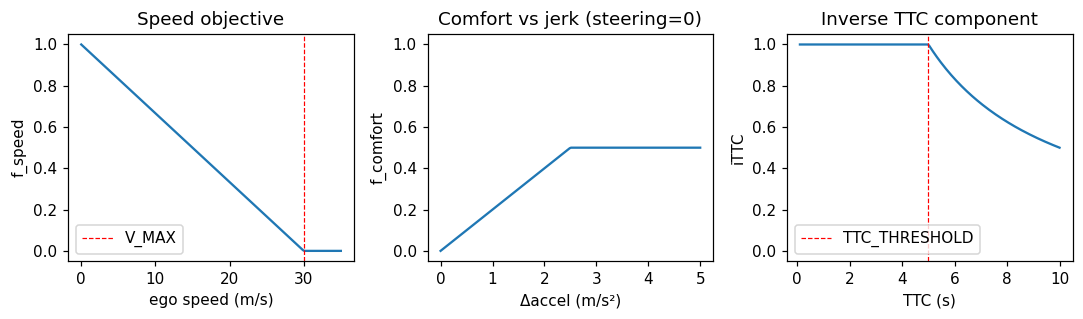

In [4]:
from envs.objectives import compute_safety, compute_speed, compute_comfort

# --- f_speed: linear deviation from V_MAX = 30 m/s ---
speeds = np.linspace(0, 35, 200)
f_speeds = [compute_speed(v) for v in speeds]

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.plot(speeds, f_speeds)
plt.axvline(30, color="r", ls="--", lw=0.8, label="V_MAX")
plt.xlabel("ego speed (m/s)"); plt.ylabel("f_speed"); plt.title("Speed objective")
plt.legend(); plt.ylim(-0.05, 1.05)

# --- f_comfort: jerk component vs Δacceleration ---
dt = 0.5  # policy_frequency = 2 Hz
delta_a = np.linspace(0, 5, 200)   # m/s²
jerks = [compute_comfort(da, 0.0, 0.0, 20.0, dt) for da in delta_a]

plt.subplot(1, 3, 2)
plt.plot(delta_a, jerks)
plt.xlabel("Δaccel (m/s²)"); plt.ylabel("f_comfort"); plt.title("Comfort vs jerk (steering=0)")
plt.ylim(-0.05, 1.05)

# --- iTTC component: TTC_THRESHOLD / TTC ---
ttcs = np.linspace(0.1, 10, 200)
ittcs = np.clip(5.0 / ttcs, 0, 1)

plt.subplot(1, 3, 3)
plt.plot(ttcs, ittcs)
plt.axvline(5, color="r", ls="--", lw=0.8, label="TTC_THRESHOLD")
plt.xlabel("TTC (s)"); plt.ylabel("iTTC"); plt.title("Inverse TTC component")
plt.legend(); plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## 3 · Policy and Critic Networks

In [5]:
from models.policy import ConditionedPolicy
from models.critic import VectorCritic

with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

pc = config["policy"]

policy = ConditionedPolicy(
    obs_dim=pc["obs_dim"],
    lam_dim=pc["lam_dim"],
    hidden_dim=pc["hidden_dim"],
    n_actions=pc["n_actions"],
)

critic = VectorCritic(
    obs_dim=pc["obs_dim"],
    lam_dim=pc["lam_dim"],
    hidden_dim=pc["hidden_dim"],
)

n_policy = sum(p.numel() for p in policy.parameters())
n_critic = sum(p.numel() for p in critic.parameters())
print(f"Policy parameters : {n_policy:,}")
print(f"Critic parameters : {n_critic:,}")
print()
print(policy)

Policy parameters : 74,501
Critic parameters : 73,987

ConditionedPolicy(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=5, bias=True)
  )
)


In [6]:
# Test forward pass with a random observation and λ
obs_t = torch.tensor(obs.flatten(), dtype=torch.float32)
lam   = np.array([1/3, 1/3, 1/3])
lam_t = torch.tensor(lam, dtype=torch.float32)

logits = policy(obs_t, lam_t)
values = critic(obs_t, lam_t)

action, log_prob = policy.act(obs_t, lam_t)

action_names = ["LANE_LEFT", "IDLE", "LANE_RIGHT", "FASTER", "SLOWER"]

print("Logits :", logits.detach().numpy().round(3))
print("Probs  :", torch.softmax(logits, dim=-1).detach().numpy().round(3))
print(f"Sampled: {action_names[action]} (log_prob={log_prob.item():.3f})")
print()
print("Critic values [V_safety, V_speed, V_comfort]:", values.detach().numpy().round(4))

Logits : [-0.065 -0.009 -0.027 -0.06   0.085]
Probs  : [0.19  0.201 0.197 0.191 0.221]
Sampled: LANE_RIGHT (log_prob=-1.623)

Critic values [V_safety, V_speed, V_comfort]: [ 0.0869 -0.0617  0.1586]


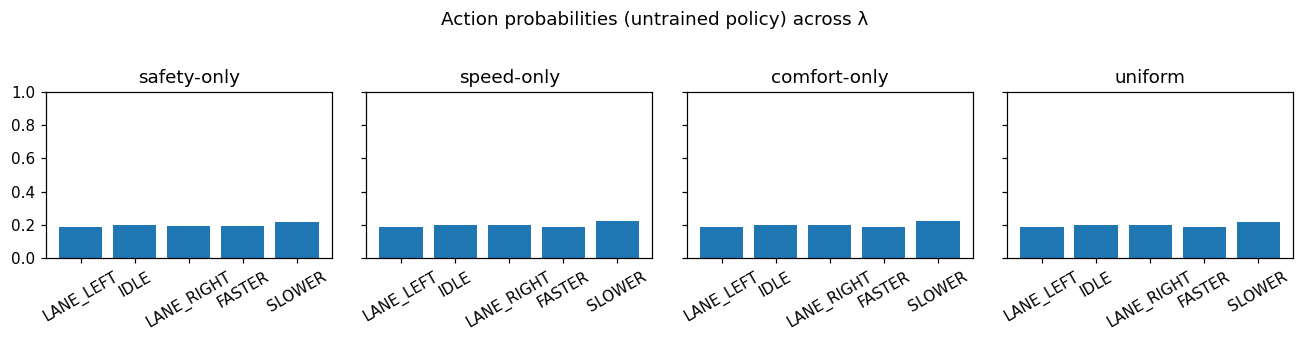

In [7]:
# Visualise how action probabilities shift across different λ preferences
lam_grid = [
    ("safety-only",  np.array([1.0, 0.0, 0.0])),
    ("speed-only",   np.array([0.0, 1.0, 0.0])),
    ("comfort-only", np.array([0.0, 0.0, 1.0])),
    ("uniform",      np.array([1/3, 1/3, 1/3])),
]

fig, axes = plt.subplots(1, len(lam_grid), figsize=(12, 3), sharey=True)
for ax, (label, lam_val) in zip(axes, lam_grid):
    lam_t_val = torch.tensor(lam_val, dtype=torch.float32)
    probs = torch.softmax(policy(obs_t, lam_t_val), dim=-1).detach().numpy()
    ax.bar(action_names, probs)
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Action probabilities (untrained policy) across λ", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Rollout Collection

In [8]:
from training.rollout import collect_episode, episode_summary

lam = np.array([1/3, 1/3, 1/3])

returns, log_probs, values, entropies = collect_episode(
    env, policy, critic, lam, gamma=0.99
)

print(f"Episode length    : {len(returns)} steps")
print(f"returns shape     : {returns.shape}   (T x 3)")
print(f"log_probs shape   : {log_probs.shape}  (T,)")
print(f"values shape      : {values.shape}   (T x 3)")
print(f"entropies shape   : {entropies.shape} (T,)")
print()
summary = episode_summary(returns)
print("Episode summary:")
for k, v in summary.items():
    print(f"  {k:12s}: {v:.4f}")


Episode length    : 15 steps
returns shape     : torch.Size([15, 3])   (T x 3)
log_probs shape   : torch.Size([15])  (T,)
values shape      : torch.Size([15, 3])   (T x 3)
entropies shape   : torch.Size([15]) (T,)

Episode summary:
  G_safety    : 0.8687
  G_speed     : 3.8030
  G_comfort   : 6.7714
  G_total     : 11.4432
  length      : 15.0000


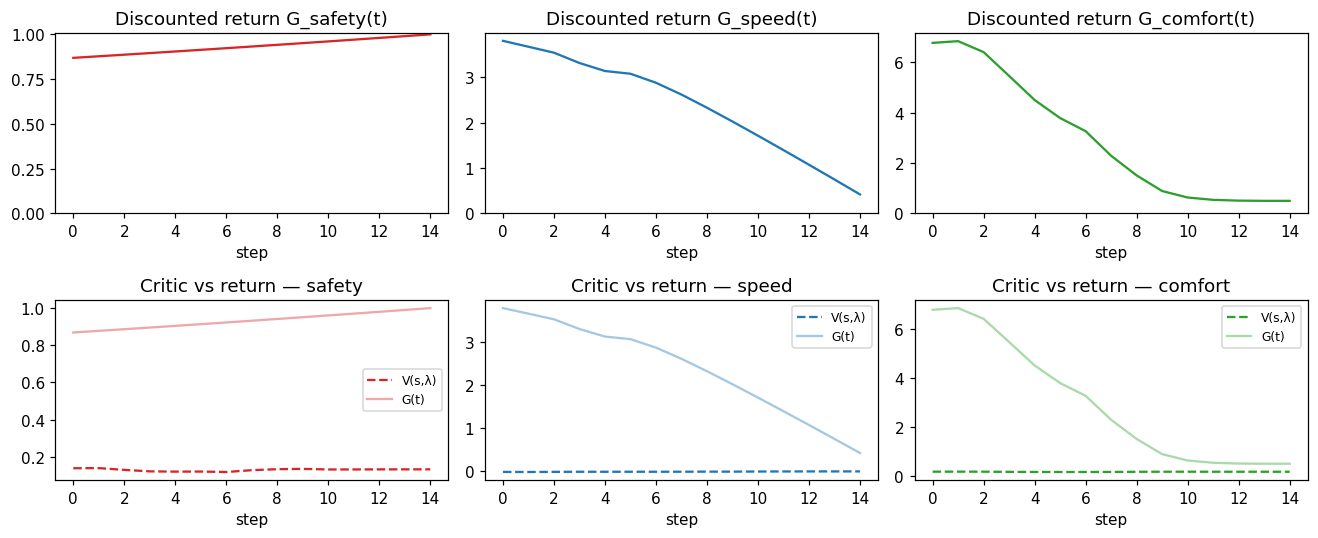

In [9]:
# Plot per-step costs and discounted returns over the episode
T = returns.shape[0]
obj_labels = ["safety", "speed", "comfort"]
colors = ["tab:red", "tab:blue", "tab:green"]

fig, axes = plt.subplots(2, 3, figsize=(12, 5))

for i, (label, color) in enumerate(zip(obj_labels, colors)):
    ax = axes[0, i]
    ax.plot(returns[:, i].detach().numpy(), color=color)
    ax.set_title(f"Discounted return G_{label}(t)")
    ax.set_xlabel("step")
    ax.set_ylim(0, None)

    ax2 = axes[1, i]
    ax2.plot(values[:, i].detach().numpy(), color=color, ls="--", label="V(s,λ)")
    ax2.plot(returns[:, i].detach().numpy(), color=color, alpha=0.4, label="G(t)")
    ax2.set_title(f"Critic vs return — {label}")
    ax2.set_xlabel("step")
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5 · Advantages

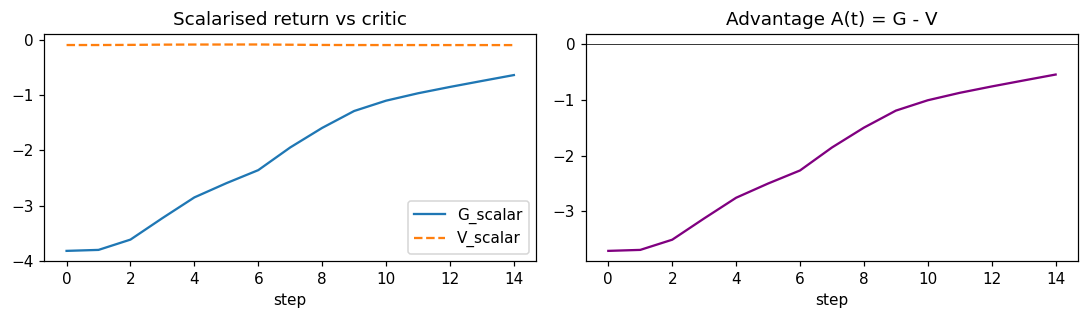

Advantage mean: -1.9974  std: 1.1656


In [10]:
lam_t = torch.tensor(lam, dtype=torch.float32)

# Scalarise: negate costs → rewards, weight by λ
reward_returns = (-returns) @ lam_t   # (T,)
reward_values  = (-values)  @ lam_t   # (T,)
advantages     = (reward_returns - reward_values).detach()

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(reward_returns.detach(), label="G_scalar")
plt.plot(reward_values.detach(),  label="V_scalar", ls="--")
plt.legend(); plt.xlabel("step"); plt.title("Scalarised return vs critic")

plt.subplot(1, 2, 2)
plt.plot(advantages, color="purple")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("step"); plt.title("Advantage A(t) = G - V")

plt.tight_layout()
plt.show()

print(f"Advantage mean: {advantages.mean().item():.4f}  std: {advantages.std().item():.4f}")

## 6 · Mini A2C Training Loop

50 episodes — enough to see the loss curve shape and verify the gradient flow.

In [11]:
tc = config["train"]

policy_fresh = ConditionedPolicy(
    obs_dim=pc["obs_dim"], lam_dim=pc["lam_dim"],
    hidden_dim=pc["hidden_dim"], n_actions=pc["n_actions"]
)
critic_fresh = VectorCritic(
    obs_dim=pc["obs_dim"], lam_dim=pc["lam_dim"], hidden_dim=pc["hidden_dim"]
)

opt_policy = torch.optim.Adam(policy_fresh.parameters(), lr=tc["learning_rate"])
opt_critic  = torch.optim.Adam(critic_fresh.parameters(), lr=tc["critic_lr"])

lam    = np.array([1/3, 1/3, 1/3])
lam_t  = torch.tensor(lam, dtype=torch.float32)
GAMMA         = tc["gamma"]
ENTROPY_COEF  = tc.get("entropy_coef", 0.01)
N_EPISODES    = 500

history = {"policy_loss": [], "critic_loss": [], "G_safety": [], "G_speed": [], "G_comfort": []}

env2 = MOHighwayEnv(config=config.get("env", {}))
for ep in range(1, N_EPISODES + 1):
    ret, lps, vals, ents = collect_episode(env2, policy_fresh, critic_fresh, lam, gamma=GAMMA)

    # costs: lower is better. scalar advantage = lambda . (G - V)
    scalar_ret  = (ret  @ lam_t)          # (T,)
    scalar_vals = (vals @ lam_t)           # (T,)
    adv = (scalar_ret - scalar_vals).detach()

    policy_loss = (adv * lps).mean() - ENTROPY_COEF * ents.mean()
    critic_loss = ((ret.detach() - vals) ** 2).mean()

    opt_policy.zero_grad()
    policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_fresh.parameters(), 0.5)
    opt_policy.step()

    opt_critic.zero_grad()
    critic_loss.backward()
    torch.nn.utils.clip_grad_norm_(critic_fresh.parameters(), 0.5)
    opt_critic.step()

    s = episode_summary(ret)
    history["policy_loss"].append(policy_loss.item())
    history["critic_loss"].append(critic_loss.item())
    history["G_safety"].append(s["G_safety"])
    history["G_speed"].append(s["G_speed"])
    history["G_comfort"].append(s["G_comfort"])

    if ep % 20 == 0:
        print(f"ep {ep:3d} | policy_loss={policy_loss.item():+.4f} | "
              f"critic_loss={critic_loss.item():.4f} | "
              f"G=[{s["G_safety"]:.3f}, {s["G_speed"]:.3f}, {s["G_comfort"]:.3f}]")

env2.close()


ep  20 | policy_loss=+0.8944 | critic_loss=1.4591 | G=[1.158, 0.678, 5.847]
ep  40 | policy_loss=+2.8431 | critic_loss=5.2396 | G=[1.249, 0.408, 2.829]
ep  60 | policy_loss=+2.0416 | critic_loss=3.0496 | G=[1.315, 0.128, 3.267]
ep  80 | policy_loss=+1.1363 | critic_loss=1.1954 | G=[0.990, 0.839, 3.710]
ep 100 | policy_loss=-0.3873 | critic_loss=2.7947 | G=[2.306, 1.252, 7.985]
ep 120 | policy_loss=-1.1136 | critic_loss=2.4336 | G=[2.476, 2.462, 7.108]
ep 140 | policy_loss=+0.8979 | critic_loss=1.1748 | G=[2.321, 0.844, 4.567]
ep 160 | policy_loss=-0.9645 | critic_loss=1.3437 | G=[3.301, 0.641, 5.333]
ep 180 | policy_loss=-1.5259 | critic_loss=3.6404 | G=[3.573, 0.442, 8.431]
ep 200 | policy_loss=+1.4760 | critic_loss=0.7260 | G=[1.821, 0.313, 2.626]
ep 220 | policy_loss=-0.6973 | critic_loss=1.4831 | G=[3.674, 1.181, 4.896]
ep 240 | policy_loss=+0.6544 | critic_loss=1.0435 | G=[3.280, 0.388, 1.751]
ep 260 | policy_loss=+0.0261 | critic_loss=0.3802 | G=[3.466, 0.762, 3.994]
ep 280 | pol

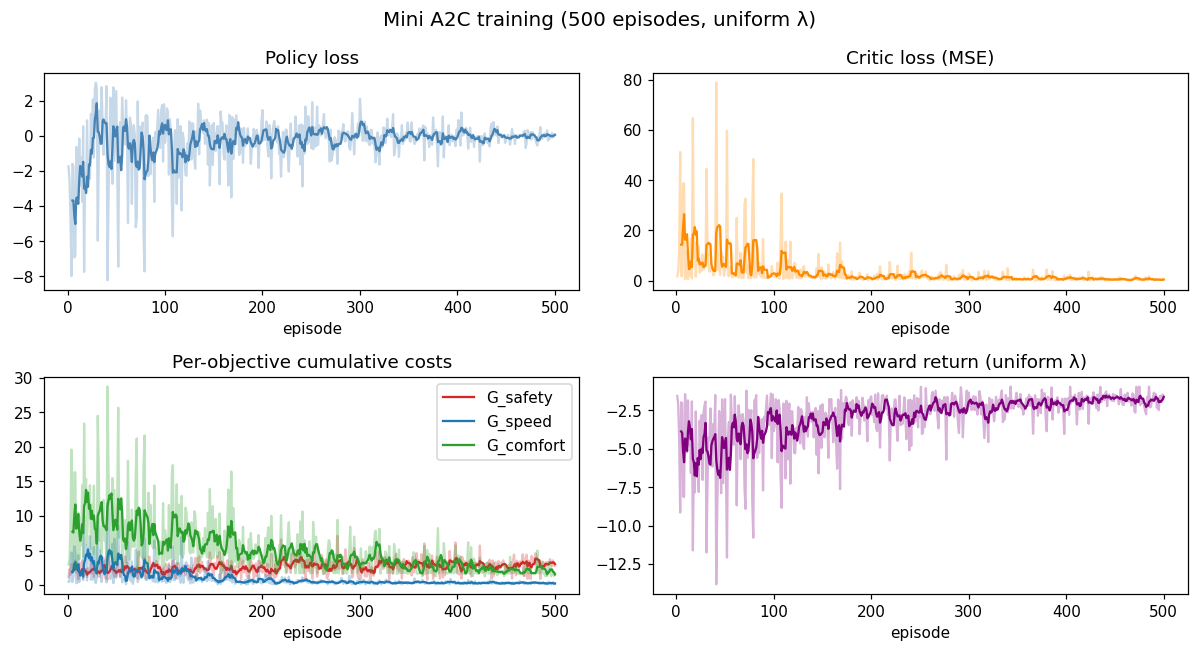

In [12]:
def smooth(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode="valid")

eps = np.arange(1, N_EPISODES + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))

axes[0,0].plot(eps, history["policy_loss"], alpha=0.3, color="steelblue")
axes[0,0].plot(eps[4:], smooth(history["policy_loss"]), color="steelblue")
axes[0,0].set_title("Policy loss"); axes[0,0].set_xlabel("episode")

axes[0,1].plot(eps, history["critic_loss"], alpha=0.3, color="darkorange")
axes[0,1].plot(eps[4:], smooth(history["critic_loss"]), color="darkorange")
axes[0,1].set_title("Critic loss (MSE)"); axes[0,1].set_xlabel("episode")

for label, color in [("G_safety", "tab:red"), ("G_speed", "tab:blue"), ("G_comfort", "tab:green")]:
    axes[1,0].plot(eps, history[label], alpha=0.3, color=color)
    axes[1,0].plot(eps[4:], smooth(history[label]), color=color, label=label)
axes[1,0].set_title("Per-objective cumulative costs"); axes[1,0].set_xlabel("episode")
axes[1,0].legend()

# Scalarised return
g_scalar = -(np.array(history["G_safety"]) + np.array(history["G_speed"]) + np.array(history["G_comfort"])) / 3
axes[1,1].plot(eps, g_scalar, alpha=0.3, color="purple")
axes[1,1].plot(eps[4:], smooth(g_scalar), color="purple")
axes[1,1].set_title("Scalarised reward return (uniform λ)")
axes[1,1].set_xlabel("episode")

plt.suptitle(f"Mini A2C training ({N_EPISODES} episodes, uniform λ)", fontsize=13)
plt.tight_layout()
plt.show()

## 7 · Pareto Set Learning (PSL) with LibMOON

Sections 1–6 verified the RL loop on a *fixed* preference. Now we use **LibMOON's EPO solver** to train a single network that handles *all* preferences. After training, we'll show the same network producing different driving styles by changing only the input λ — no retraining.

### 7.1 · Smoke-test the LibMOON EPO solver

EPO (Exact Pareto Optimal) takes a Jacobian J ∈ ℝ³ˣⁿ (one row per objective gradient) and a current loss vector, then returns mixing weights α ∈ ℝ³ that produce a Pareto-stationary descent direction matching the target preference.

In [13]:
from libmoon.solver.gradient.methods.epo_solver import EPOCore

# Build a synthetic 3-objective problem with n_var=10 parameters
torch.manual_seed(0)
J_synthetic = torch.randn(3, 10)            # gradients per objective
losses_synthetic = torch.tensor([0.6, 0.3, 0.1])   # current per-objective losses

prefs_to_test = [
    np.array([0.7, 0.2, 0.1]),   # safety-leaning
    np.array([0.1, 0.7, 0.2]),   # speed-leaning
    np.array([0.1, 0.2, 0.7]),   # comfort-leaning
    np.array([1/3, 1/3, 1/3]),   # uniform
]

for p in prefs_to_test:
    p_t = torch.tensor(p, dtype=torch.float32).unsqueeze(0)   # (1, 3)
    core = EPOCore(n_var=10, prefs=p_t)
    alpha = core.get_alpha(J_synthetic, losses_synthetic, idx=0).numpy()
    g_combined = alpha @ J_synthetic.numpy()
    print(f"pref={p.round(2)}  →  α={alpha.round(3)}   "
          f"||combined grad||={np.linalg.norm(g_combined):.3f}")

pref=[0.7 0.2 0.1]  →  α=[0. 1. 0.]   ||combined grad||=1.574
pref=[0.1 0.7 0.2]  →  α=[1. 0. 0.]   ||combined grad||=3.212
pref=[0.1 0.2 0.7]  →  α=[1. 0. 0.]   ||combined grad||=3.212
pref=[0.33 0.33 0.33]  →  α=[1. 0. 0.]   ||combined grad||=3.212


objc[89679]: Class SDLApplication is implemented in both /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x141f092c8) and /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x332380890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[89679]: Class SDLAppDelegate is implemented in both /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x141f09318) and /Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x3323808e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[89679]: Class SDLTranslatorResponder is implemented in both /Users/Ravi

**What to look for:** EPO returns α with most weight on the under-served objective. Notice α is *not* equal to the preference vector itself — EPO computes the descent direction that makes objectives evolve toward the *Pareto-optimal ratio*, which depends on current loss values.

### 7.2 · Run PSL training

Each PSL update samples K preference vectors from the Dirichlet, runs N episodes per preference, builds 3 per-objective gradient vectors via separate backward passes, and uses EPO to merge them.

We use a small budget here for notebook responsiveness. Increase `n_updates` for production runs.

In [14]:
from training.psl_trainer import PSLTrainer, PSLConfig
import os

psl_cfg = PSLConfig(
    n_pref_samples=8,          # K — preferences sampled per update
    n_episodes_per_pref=15,    # N — episodes per lambda for gradient estimation
    n_updates=300,             # outer steps (~2.5 hrs sequential; ~20 min parallel)
    gamma=0.99,
    learning_rate=3e-4,
    critic_lr=1e-3,
    entropy_coef=0.01,
    grad_clip=0.5,
    log_interval=5,
    save_interval=25,
    checkpoint_dir="checkpoints/psl",
    seed=42,
    n_workers=8,               # parallel processes — one per preference vector
)

trainer = PSLTrainer(psl_cfg, env_config=config.get("env", {}))
print(f"Policy n_var = {trainer.n_var:,}")
print(f"Episodes per update = {psl_cfg.n_pref_samples * psl_cfg.n_episodes_per_pref}  "
      f"(running {psl_cfg.n_workers} preferences in parallel)")
print(f"Total episodes = {psl_cfg.n_pref_samples * psl_cfg.n_episodes_per_pref * psl_cfg.n_updates:,}")
print()

trainer.train()


Policy n_var = 74,501
Episodes per update = 120  (running 8 preferences in parallel)
Total episodes = 36,000



/Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/Ravi/Desktop/UMCP/604/Project/autonomous-driving-psl/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as

PSL upd   5/300  G=[s=0.101 v=0.154 c=0.557]  α=[0.12 0.62 0.25]  L_crit=0.0016
PSL upd  10/300  G=[s=0.104 v=0.116 c=0.535]  α=[0.25 0.25 0.50]  L_crit=0.0023
PSL upd  15/300  G=[s=0.120 v=0.106 c=0.540]  α=[0.50 0.25 0.25]  L_crit=0.0007
PSL upd  20/300  G=[s=0.111 v=0.092 c=0.489]  α=[0.75 -0.00 0.25]  L_crit=0.0012
PSL upd  25/300  G=[s=0.142 v=0.083 c=0.473]  α=[0.25 -0.00 0.75]  L_crit=0.0013
PSL upd  30/300  G=[s=0.128 v=0.082 c=0.491]  α=[0.62 0.12 0.25]  L_crit=0.0006
PSL upd  35/300  G=[s=0.147 v=0.064 c=0.441]  α=[0.40 -0.00 0.60]  L_crit=0.0001
PSL upd  40/300  G=[s=0.148 v=0.052 c=0.448]  α=[0.14 0.25 0.61]  L_crit=0.0001
PSL upd  45/300  G=[s=0.158 v=0.058 c=0.453]  α=[0.12 0.38 0.50]  L_crit=0.0001
PSL upd  50/300  G=[s=0.155 v=0.047 c=0.385]  α=[0.62 -0.00 0.38]  L_crit=0.0001
PSL upd  55/300  G=[s=0.173 v=0.043 c=0.353]  α=[0.24 0.22 0.53]  L_crit=0.0000
PSL upd  60/300  G=[s=0.180 v=0.040 c=0.326]  α=[0.25 0.12 0.62]  L_crit=0.0000
PSL upd  65/300  G=[s=0.183 v=0.033 

### 7.3 · Visualise the EPO mixing weights and per-objective costs

Each update produces a per-batch mean of the EPO α weights. As training proceeds, α concentrates on whichever objective is currently the bottleneck — a sign that EPO is steering toward the Pareto frontier rather than getting pulled by any single preference.

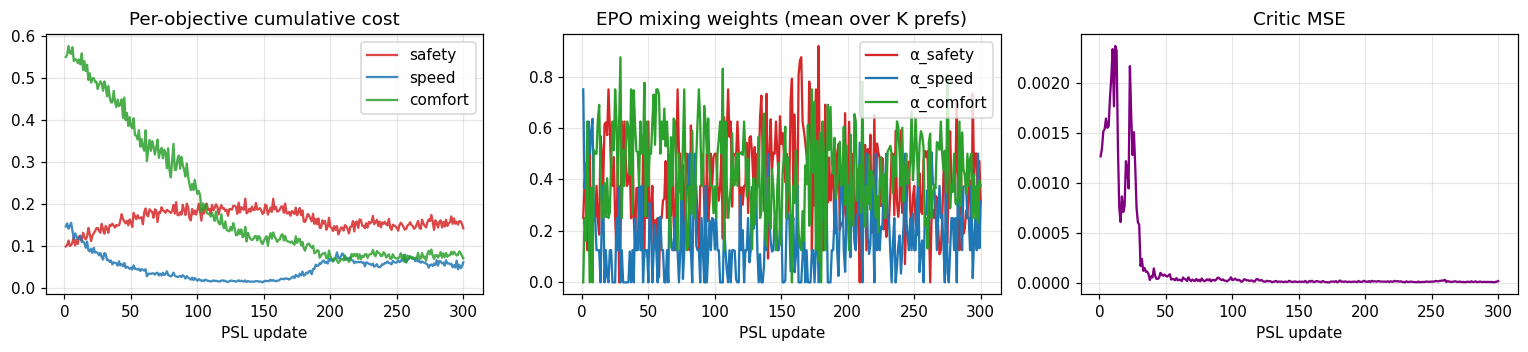

In [15]:
import matplotlib.pyplot as plt

hist = trainer.history
steps = np.array(hist.update)
alpha_arr = np.stack(hist.alpha_mean)        # (n_updates, 3)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))

# Per-objective costs
for label, color, key in [
    ("safety",  "tab:red",   hist.G_safety),
    ("speed",   "tab:blue",  hist.G_speed),
    ("comfort", "tab:green", hist.G_comfort),
]:
    axes[0].plot(steps, key, color=color, label=label, alpha=0.85)
axes[0].set_title("Per-objective cumulative cost")
axes[0].set_xlabel("PSL update"); axes[0].legend(); axes[0].grid(alpha=0.3)

# EPO α weights
for i, (lab, color) in enumerate(zip(["α_safety", "α_speed", "α_comfort"],
                                     ["tab:red", "tab:blue", "tab:green"])):
    axes[1].plot(steps, alpha_arr[:, i], color=color, label=lab)
axes[1].set_title("EPO mixing weights (mean over K prefs)")
axes[1].set_xlabel("PSL update"); axes[1].legend(); axes[1].grid(alpha=0.3)

# Critic loss
axes[2].plot(steps, hist.L_critic, color="purple")
axes[2].set_title("Critic MSE")
axes[2].set_xlabel("PSL update"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 8 · Significance of the Pareto Set — Adapting Without Retraining

This is the **core demo**. We freeze the trained PSL policy and query it with three extreme preference vectors:
- λ = (1, 0, 0): safety only
- λ = (0, 1, 0): speed only
- λ = (0, 0, 1): comfort only

If PSL works, the **same set of weights** should yield three meaningfully different behaviours.

In [16]:
from evaluation.evaluate import evaluate_policy_at_lambda

trained_policy = trainer.policy
adapt_env = trainer.env

extremes = {
    "safety-only  λ=(1,0,0)":  np.array([0.99, 0.005, 0.005]),
    "speed-only   λ=(0,1,0)":  np.array([0.005, 0.99, 0.005]),
    "comfort-only λ=(0,0,1)":  np.array([0.005, 0.005, 0.99]),
    "uniform      λ=(1/3,1/3,1/3)": np.array([1/3, 1/3, 1/3]),
}

N_EVAL = 10
adaptation = {}
for label, lam_val in extremes.items():
    res = evaluate_policy_at_lambda(
        trained_policy, lam_val,
        n_episodes=N_EVAL, env=adapt_env, greedy=True,
    )
    adaptation[label] = res["mean"]
    print(f"{label}  ->  safety={res["mean"][0]:.3f}  "
          f"speed={res["mean"][1]:.3f}  comfort={res["mean"][2]:.3f}  "
          f"(+/-{res["std"].round(3)})")


safety-only  λ=(1,0,0)  ->  safety=0.191  speed=0.177  comfort=0.027  (+/-[0.086 0.008 0.016])
speed-only   λ=(0,1,0)  ->  safety=0.082  speed=0.171  comfort=0.013  (+/-[0.074 0.004 0.013])
comfort-only λ=(0,0,1)  ->  safety=0.131  speed=0.174  comfort=0.018  (+/-[0.091 0.007 0.014])
uniform      λ=(1/3,1/3,1/3)  ->  safety=0.109  speed=0.171  comfort=0.017  (+/-[0.056 0.003 0.008])


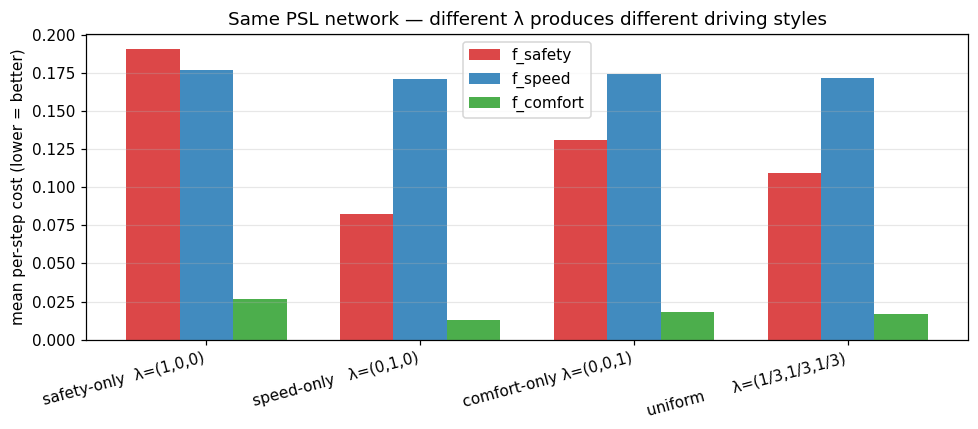

In [17]:
from evaluation.visualize import plot_lambda_adaptation

plot_lambda_adaptation(
    adaptation,
    title="Same PSL network — different λ produces different driving styles",
)
plt.show()

**How to read this chart.** Each group of bars is the *same* network evaluated under a different preference vector. If the safety-only condition has a low red bar (low f_safety cost) while the speed-only condition has a low blue bar (low f_speed cost), then PSL succeeded: the network's behaviour shifted in response to λ alone.

In practice, a 30-update training budget is too small to make these differences large; expect modest separation. Bumping `n_updates` to 200+ produces clearer adaptation.

## 9 · Pareto Surface — Sweeping the Simplex

Finally, we evaluate the trained PSL policy on a triangular grid of λ values to visualise the learned Pareto surface in objective space.

In [18]:
from evaluation.evaluate import evaluate_policy_grid
from evaluation.visualize import plot_pareto_3d, plot_pareto_projections

grid = evaluate_policy_grid(
    trained_policy,
    n_per_side=7,        # 36 grid points on the simplex
    n_episodes=5,
    env=adapt_env,
    greedy=True,
    verbose=True,
)
print(f"Grid shape: {grid["lambdas"].shape}, costs shape: {grid["costs"].shape}")


[  1/36] λ=(0.00,0.00,1.00) → safety=0.106  speed=0.169  comfort=0.011
[  2/36] λ=(0.00,0.14,0.86) → safety=0.078  speed=0.170  comfort=0.010
[  3/36] λ=(0.00,0.29,0.71) → safety=0.146  speed=0.172  comfort=0.022
[  4/36] λ=(0.00,0.43,0.57) → safety=0.166  speed=0.177  comfort=0.023
[  5/36] λ=(0.00,0.57,0.43) → safety=0.192  speed=0.174  comfort=0.033
[  6/36] λ=(0.00,0.71,0.29) → safety=0.160  speed=0.170  comfort=0.016
[  7/36] λ=(0.00,0.86,0.14) → safety=0.114  speed=0.172  comfort=0.019
[  8/36] λ=(0.00,1.00,0.00) → safety=0.131  speed=0.171  comfort=0.013
[  9/36] λ=(0.14,0.00,0.86) → safety=0.173  speed=0.171  comfort=0.019
[ 10/36] λ=(0.14,0.14,0.71) → safety=0.162  speed=0.174  comfort=0.021
[ 11/36] λ=(0.14,0.29,0.57) → safety=0.147  speed=0.173  comfort=0.025
[ 12/36] λ=(0.14,0.43,0.43) → safety=0.066  speed=0.170  comfort=0.009
[ 13/36] λ=(0.14,0.57,0.29) → safety=0.090  speed=0.172  comfort=0.015
[ 14/36] λ=(0.14,0.71,0.14) → safety=0.097  speed=0.172  comfort=0.014
[ 15/3

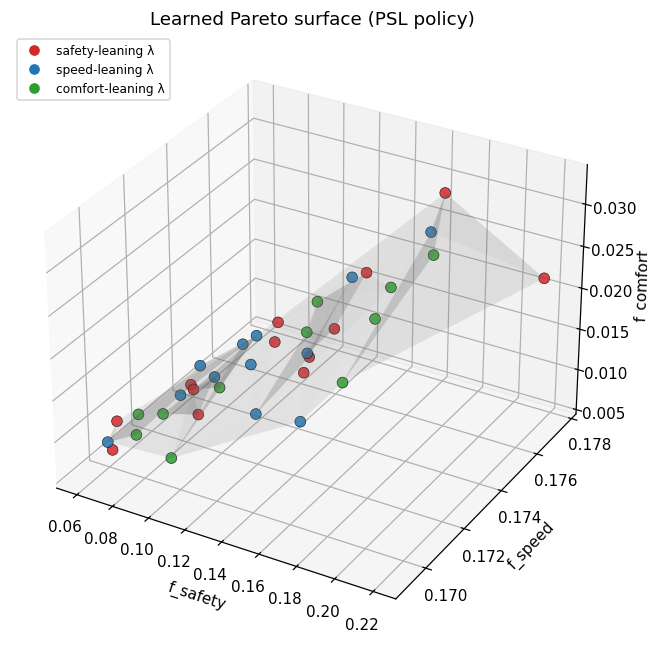

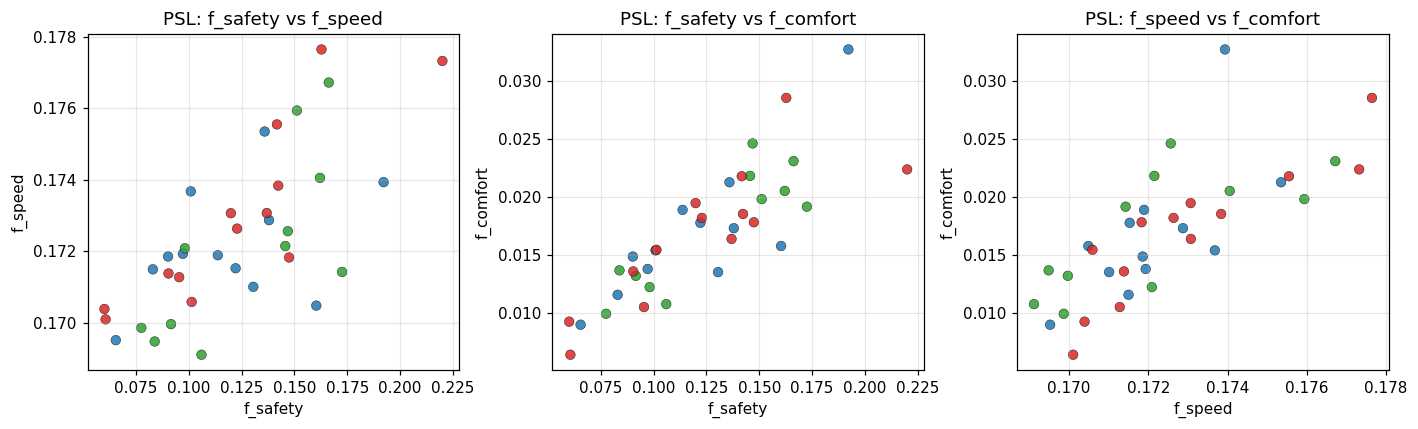

In [19]:
fig3d, _ = plot_pareto_3d(grid, title="Learned Pareto surface (PSL policy)")
plt.show()

figp, _ = plot_pareto_projections(grid, title_prefix="PSL")
plt.show()

**Reading the surface.** Each point is the mean per-step cost the policy achieves at one preference λ. Points are colour-coded by the dominant objective in their λ.

In a well-trained PSL model, points cluster in different regions of objective space — the safety-leaning λ produces low-f_safety / higher-cost-elsewhere outcomes, etc. The surface itself approximates the Pareto front: each point is non-dominated for its own preference.

In [20]:
# Cleanup
trainer.close()
print('PSL trainer closed.')

PSL trainer closed.


In [ ]:
l